# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [105]:
df = pd.read_csv('data/RFM_base.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,frequency,monetary,max_order_date
customer_unique_id,,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,2017-10-02
af07308b275d755c9edb36a90c618231,85,1,118.70,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,1,45.00,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,2018-02-13
...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,1,174.90,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99,2017-08-27


In [106]:
offset = -1
n_periods_max = 24
n_periods_min = 8

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods_max, n_periods_min, offset))
list_offsets

[24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9]

In [107]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [108]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-06-05


In [109]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9', 'df_10', 'df_11', 'df_12', 'df_13', 'df_14', 'df_15', 'df_16'])


In [110]:
for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print(df['max_order_date'].max())
    print()

df_1:
(70279, 4)
2018-05-01

df_2:
(72213, 4)
2018-05-08

df_3:
(74169, 4)
2018-05-15

df_4:
(75661, 4)
2018-05-22

df_5:
(76489, 4)
2018-05-29

df_6:
(77672, 4)
2018-06-05

df_7:
(79210, 4)
2018-06-12

df_8:
(80644, 4)
2018-06-19

df_9:
(82089, 4)
2018-06-26

df_10:
(83398, 4)
2018-07-03

df_11:
(84448, 4)
2018-07-10

df_12:
(85605, 4)
2018-07-17

df_13:
(87348, 4)
2018-07-24

df_14:
(88992, 4)
2018-07-31

df_15:
(91157, 4)
2018-08-07

df_16:
(92980, 4)
2018-08-14



In [111]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print()

df_1:
(70279, 3)

df_2:
(72213, 3)

df_3:
(74169, 3)

df_4:
(75661, 3)

df_5:
(76489, 3)

df_6:
(77672, 3)

df_7:
(79210, 3)

df_8:
(80644, 3)

df_9:
(82089, 3)

df_10:
(83398, 3)

df_11:
(84448, 3)

df_12:
(85605, 3)

df_13:
(87348, 3)

df_14:
(88992, 3)

df_15:
(91157, 3)

df_16:
(92980, 3)



In [112]:
dfs['df_1']

,recency,frequency,monetary
customer_unique_id,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
7c142cf63193a1473d2e66489a9ae977,333,1,45.00
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
80bb27c7c16e8f973207a5086ab329e2,465,1,147.90
36edbb3fb164b1f16485364b6fb04c73,554,1,49.90
...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
da62f9e57a76d978d02ab5362c509660,253,1,174.90
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99


# train kmeans datasets


In [114]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['frequency', 'monetary']
['recency']


In [115]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [116]:
# drop max_order_date column
X_stds = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_stds[f'X_{name_split[1]}'] = df

In [117]:
X_stds.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9', 'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15', 'X_16'])

In [118]:
for name, df in X_stds.items():
    print(f'{name}:')
    print(df.shape)
    print()

X_1:
(70279, 3)

X_2:
(72213, 3)

X_3:
(74169, 3)

X_4:
(75661, 3)

X_5:
(76489, 3)

X_6:
(77672, 3)

X_7:
(79210, 3)

X_8:
(80644, 3)

X_9:
(82089, 3)

X_10:
(83398, 3)

X_11:
(84448, 3)

X_12:
(85605, 3)

X_13:
(87348, 3)

X_14:
(88992, 3)

X_15:
(91157, 3)

X_16:
(92980, 3)



In [119]:
X_stds['X_1']

,recency,frequency,monetary
0,1.110223e-16,-0.275808,0.227718
1,-3.469447e-18,-0.693065,-0.143910
2,-3.469447e-18,-1.640992,-0.831817
3,-3.469447e-18,0.593994,0.899811
4,-3.469447e-18,-0.576461,1.603531
...,...,...,...
70274,-3.469447e-18,-0.169987,1.864461
70275,-3.469447e-18,0.765315,-0.776468
70276,-3.469447e-18,0.930065,0.512369
70277,-3.469447e-18,1.474337,-0.547165


## Check training first dataset

In [ ]:
X_std = X_stds['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

BatchKmeans 2 clusters, sil score : 0.37154033829389316
BatchKmeans 3 clusters, sil score : 0.3757516925584039
BatchKmeans 4 clusters, sil score : 0.35802484347731905
BatchKmeans 5 clusters, sil score : 0.3319125897722945


In [ ]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

In [ ]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [97]:
clusters_num = 4

dict_Kmeans_X = {}

for name, df in X_stds.items():
    kmeans = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(df)
    dict_Kmeans_X[f'kmeans_{name}'] = kmeans

Initialization complete
Iteration 0, inertia 65156.872786134874.
Iteration 1, inertia 54449.86690389723.
Iteration 2, inertia 52036.34660217526.
Iteration 3, inertia 51360.46787390424.
Iteration 4, inertia 51162.457287302095.
Iteration 5, inertia 51074.26582755182.
Iteration 6, inertia 51050.5347513327.
Iteration 7, inertia 51042.93986158754.
Iteration 8, inertia 51039.146239548885.
Iteration 9, inertia 51035.8334556306.
Iteration 10, inertia 51032.26111214857.
Iteration 11, inertia 51029.514859623785.
Converged at iteration 11: center shift 1.4117563979061644e-05 within tolerance 6.666666666666529e-05.
Initialization complete
Iteration 0, inertia 73485.81625231067.
Iteration 1, inertia 66534.36623034325.
Iteration 2, inertia 61671.06240221585.
Iteration 3, inertia 57764.74392702206.
Iteration 4, inertia 55507.885114015684.
Iteration 5, inertia 54556.74844127055.
Iteration 6, inertia 54175.60870933696.
Iteration 7, inertia 53998.44040546325.
Iteration 8, inertia 53876.56132507819.
Iter

# Compute ARI

In [98]:
scores = []
first_kmeans = dict_Kmeans_X['kmeans_X_1']

for name, kmeans in dict_Kmeans_X.items():
    X_name = name.replace("kmeans_", "")
    ari = adjusted_rand_score(kmeans.labels_, first_kmeans.predict(X_stds[X_name]))
    scores.append(ari)

#periodes = 

In [99]:
scores

[1.0,
 0.9928969957853311,
 0.9919748054121106,
 0.7807545914997522,
 0.7852370206076842,
 0.8728123977112082,
 0.8836139033013236,
 0.8273272198311072,
 0.883816444041227]

In [100]:
scores_len = len(scores)
periodes = list(range(0, scores_len, 1))

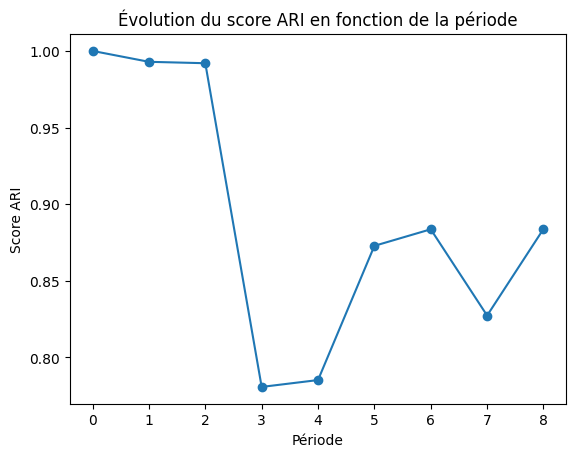

In [101]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()